In [72]:
%pip install --upgrade face_recognition
%pip install ultralytics

import numpy as np
import cv2
import face_recognition
from ultralytics import YOLO

import matplotlib.pyplot as plt
import glob

In [4]:
model = YOLO('yolov8n.pt')

(4, 128)
['Thiago', 'Thiago', 'Thiago', 'Thiago']


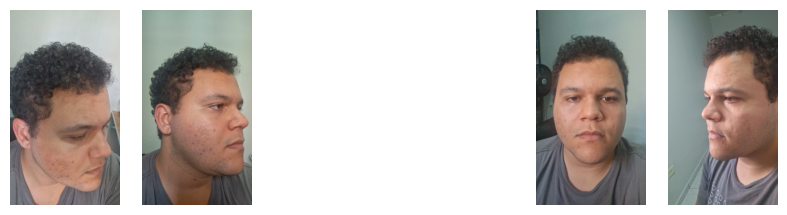

In [85]:
plt.figure(figsize=(15,5))

faces_to_test_files = glob.glob('/content/faces/*.jpeg')
know_encondings = []
know_names = []

for i, file in enumerate(faces_to_test_files):
  image = face_recognition.load_image_file(file)
  face_encodings = face_recognition.face_encodings(image)

  if face_encodings:
      know_encondings.append(face_encodings[0])
      know_names.append('Thiago')
      plt.subplot(1, len(faces_to_test_files), i + 1)
      plt.imshow(image)
      plt.axis("off")


print(np.array(know_encondings).shape)
print(know_names)
plt.show()


0: 640x448 1 person, 302.6ms
Speed: 9.2ms preprocess, 302.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 448)


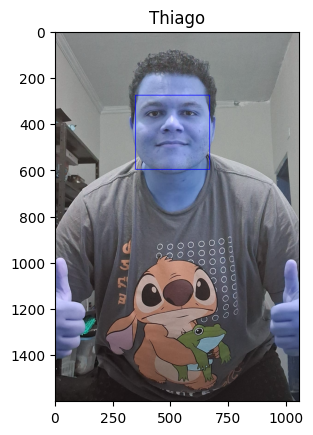

In [82]:
imagem_teste = cv2.imread("/content/valido.jpeg")
# imagem_teste = cv2.imread("/content/erro.jpeg")

results = model(imagem_teste)

for has_match in results:
  for box in has_match.boxes:
    if int(box.cls) == 0:
      x1,y1,x2,y2=map(int, box.xyxy[0])
      pessoa = imagem_teste[y1:y2, x1:x2]
      rgb = np.ascontiguousarray(imagem_teste[:,:,::-1])
      locations = face_recognition.face_locations(rgb)

      if locations is not None and locations:
        encondings = face_recognition.face_encodings(rgb, locations)
        names = []

        for enconding in encondings:
          matches = face_recognition.compare_faces(know_encondings, enconding)
          name = "Desconhecido"

          distance = face_recognition.face_distance(know_encondings, enconding)
          best_match = np.argmin(distance)

          has_match = matches[best_match]
          if has_match:
            name = know_names[best_match]

          names.append(name)

        for (top, right, bottom, left), name in zip(locations, names):
          cv2.rectangle(imagem_teste, (left,top), (right, bottom), (0,0,255), 2)
          plt.imshow(imagem_teste)
          plt.title(name)
